# Multi-Factor Momentum Trading Strategy

# Getting Started

In [717]:
# %pip install -r ../requirements.txt

### Part 0: Choosing the universe of stocks to trade on

In [718]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
TABLE_INDEX = 0  # first table on the page is the constituent list
TICKER_COL = "Symbol"

headers = {"User-Agent": "Mozilla/5.0"}  # wikipedia blocks default requests UA sometimes
resp = requests.get(WIKI_URL, headers=headers, timeout=15)

tables = pd.read_html(StringIO(resp.text))

df = tables[TABLE_INDEX]

tickers = df[TICKER_COL].astype(str).str.strip().tolist()
tickers = [t.replace(".", "-") for t in tickers]
tickers = sorted(set(tickers))
len(tickers)

503

In [719]:
# Doing a small sample for now
# import random
# random.seed(42)
# random.shuffle(tickers)
# tickers = tickers[:75]

In [720]:
if 'SPY' not in tickers: tickers += ['SPY']

In [721]:
import yfinance as yf
import datetime as dt

N_YEARS = 10
period = dict(
    start = dt.datetime.today() - dt.timedelta(days=365 * N_YEARS)
    , end   = dt.datetime.today()
)

data = yf.download(tickers, **period, auto_adjust=True)

data.tail()

[*********************100%***********************]  504 of 504 completed


Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2026-07-17  131.460007  333.739990  254.490005  145.979996  100.680000   
2026-07-20  130.259995  326.589996  253.380005  144.940002  101.660004   
2026-07-21  132.860001  327.739990  256.100006  144.100006   99.669998   
2026-07-22  133.460007  325.890015  253.300003  140.050003  100.570000   
2026-07-23  139.740005  321.660004  256.920013  137.570007  100.750000   

Price                                                                  ...  \
Ticker            ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                   ...   
2026-07-17  101.349998  143.570007  237.250000  375.359985  85.900002  ...   
2026-07-20  101.830002  144.729996  234.740005  372.459991  85.669998  ...   
2026-07-21  100.550003  140.860001  227.160004  382.809998  86.199997  ...   
2026-07-22   98.629997  140.089996  218.360001  386.730011  87.320000  ...   
2026-07-23  100.099998  138.740005  212.169998  380.200012  86.349998  ...   

Price        Volume                                                         \
Ticker           WY     WYNN      XEL       XOM      XYL      XYZ      YUM   
Date                                                                         
2026-07-17  6188300  1000100  5592600  19031400  2736000  4903300  4125000   
2026-07-20  5063800  1132300  4151000  12149200  1794200  4218800  3049900   
2026-07-21  3289100  1217700  4023800  13145300  2502300  3447100  2898400   
2026-07-22  4195900  1415200  3714500  13788700  1625900  3834100  2968100   
2026-07-23  3273513  3014125  5165606  15764898  2124261  5623680  1819020   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2026-07-17  2632400  673600  7544400  
2026-07-20  2150800  527000  5635700  
2026-07-21  1985700  949000  4827300  
2026-07-22  1179100  653800  4680700  
2026-07-23  1607226  629895  6319413  

[5 rows x 2520 columns]

In [722]:

assert not data.empty

In [723]:
assert not data.Close.isna().all(axis=0).sum()

In [724]:
assert not data.Close.isna().all(axis=1).sum()

### Part 1: Market Regime Filter
- #### Mechanism: It checks if the market index (e.g., SPY) is trading above its 200-day Simple Moving Average (SMA).
- #### Action: Long positions are only initiated or held if the market is in a bullish regime (price > 200-day SMA). If the market enters a bearish regime, all positions are exited to mitigate systemic risk.

In [725]:
close_spy = data.Close.SPY
data.Close.drop(columns=['SPY'], inplace=True)

In [726]:
# Market Regime Filter
LOOKBACK_REGIME = 200
spy_sma_200 = close_spy.rolling(LOOKBACK_REGIME).mean()
mrf_signal  = close_spy < spy_sma_200

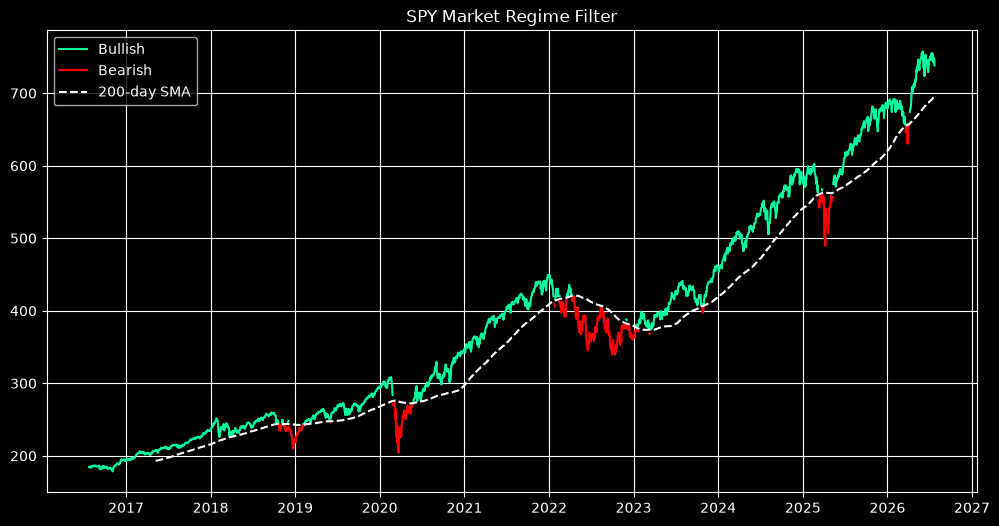

In [727]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

plt.figure(figsize=(12, 6))

# Plot SPY price when filter is ON (green)
plt.plot(
    data.index,
    close_spy.where(~mrf_signal),
    color="#00FF9D",
    label="Bullish"
)

# Plot SPY price when filter is OFF (red)
plt.plot(
    data.index,
    close_spy.where(mrf_signal),
    color="#FF0000",
    label="Bearish"
)

# Optional: plot the 200-day SMA
plt.plot(
    data.index,
    spy_sma_200,
    color="#FFFFFF",
    linestyle="--",
    label="200-day SMA"
)

plt.title("SPY Market Regime Filter")
plt.legend()
plt.grid(True)
plt.show()

### Part 2: Time-Series Momentum (TSMOM): This is a trend-following filter applied to each individual stock.
- #### Mechanism: A stock is only considered a candidate for investment if it is trading above its own 200-day SMA.

In [728]:
LOOKBACK_TSMOM = 200
def sma_200(x: pd.Series) -> pd.Series:
    return x.rolling(LOOKBACK_TSMOM).mean()

data_sma_200d = data.Close.apply(sma_200)
data_sma_200d.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-17,130.557029,273.880448,219.948821,131.239375,108.299901,94.24640,211.878051,281.94705,323.176182,67.788155,...,23.804145,110.986775,78.076951,135.820345,129.027032,67.50130,152.990678,90.940323,247.56890,112.453097
2026-07-20,130.570409,274.243840,220.092855,131.356975,108.153630,94.30190,211.393596,281.35700,323.821460,67.924443,...,23.803254,110.828119,78.076049,136.010727,128.900059,67.53640,152.978247,90.900358,247.40655,112.116284
2026-07-21,130.545945,274.608893,220.188222,131.465875,107.999707,94.35310,210.903949,280.77420,324.550289,68.065776,...,23.799833,110.645642,78.077059,136.221575,128.753106,67.57130,152.958950,90.854457,247.25960,111.772129
2026-07-22,130.523884,274.956320,220.307511,131.558675,107.852629,94.40085,210.407365,280.10860,325.286879,68.213394,...,23.797561,110.455360,78.088890,136.449546,128.596259,67.57455,152.950723,90.805968,247.09410,111.424431
2026-07-23,130.518611,275.278160,220.457752,131.645425,107.698632,94.44740,209.899231,279.43575,325.989234,68.346726,...,23.793463,110.325146,78.100395,136.680083,128.438905,67.57225,152.944750,90.754343,246.85380,111.078977


In [729]:
tsmom_filter = data.Close.gt(data_sma_200d)

<Axes: title={'center': 'Number of Stocks Above 200-Day SMA'}, xlabel='Date', ylabel='Number of Valid Stocks'>

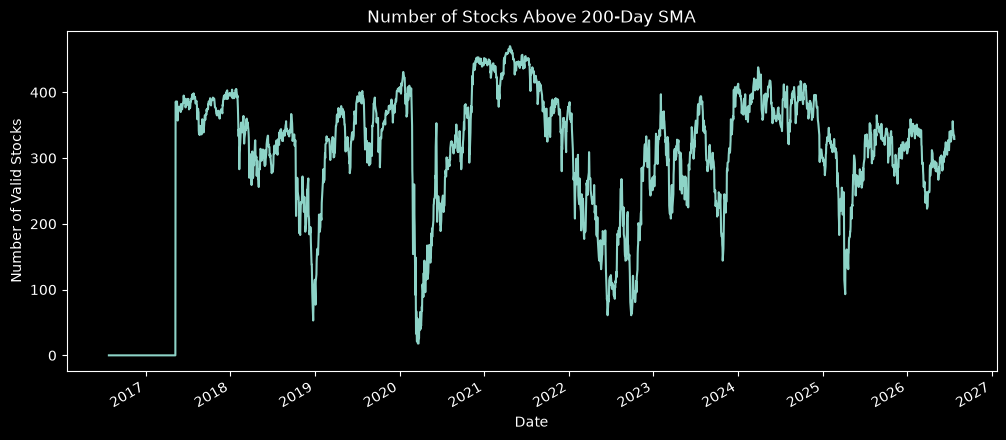

In [730]:
valid_stocks = tsmom_filter.sum(axis=1)

valid_stocks.plot(
    figsize=(12, 5),
    title="Number of Stocks Above 200-Day SMA",
    ylabel="Number of Valid Stocks",
    xlabel="Date"
)

### Part 3: Cross-Sectional Momentum: After filtering for trend, stocks are ranked against each other based on their momentum.
- #### Mechanism: Momentum is calculated over multiple lookback periods (60, 120, and 252 days) and then averaged to produce a robust momentum score.

In [731]:

cross_sect_mom_lookbacks = [60, 120, 252]
LOOKBACK_CSM = max(cross_sect_mom_lookbacks)
SKIP_DAYS = 21  # ~1 month, standard skip in 12-1 momentum

def cross_sect_mom(prices: pd.DataFrame, lookbacks: list[int] = cross_sect_mom_lookbacks, skip: int = SKIP_DAYS) -> pd.DataFrame:
    # price ~1 month ago (skip window), vs price (skip+lookback) ago
    recent = prices.shift(skip)
    raw_signal = pd.concat(
        [(recent / recent.shift(l - skip)) - 1 for l in lookbacks]
    ).groupby(level=0).mean()
    return raw_signal

csm_data = cross_sect_mom(data.Close)
csm_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-17,0.047337,0.254485,0.100894,0.030387,-0.158322,-0.009370,-0.319300,-0.299859,0.410993,0.262349,...,-0.019623,-0.054906,0.084003,0.110739,-0.131135,0.080049,0.042782,-0.015463,-0.088993,-0.384943
2026-07-20,0.008561,0.220003,0.099025,0.012419,-0.156705,-0.005939,-0.354102,-0.351115,0.401292,0.244854,...,-0.032631,-0.064495,0.061252,0.102083,-0.156654,0.046611,0.017203,-0.045559,-0.109631,-0.397813
2026-07-21,0.056219,0.221226,0.074385,0.034302,-0.165362,-0.020873,-0.452403,-0.331219,0.445843,0.206676,...,-0.026914,-0.022870,0.048151,0.087324,-0.143664,0.084678,-0.004501,-0.023721,-0.086433,-0.384361
2026-07-22,0.059184,0.220158,0.163981,0.013591,-0.161902,-0.004826,-0.462969,-0.341753,0.468680,0.236813,...,-0.024507,-0.037078,0.063568,0.092881,-0.129087,0.031249,-0.003377,-0.026286,-0.044269,-0.401438
2026-07-23,0.048351,0.206813,0.182556,0.011301,-0.144772,0.001507,-0.448536,-0.322858,0.359385,0.214469,...,-0.029672,-0.024517,0.075288,0.095193,-0.147652,0.030522,0.002134,-0.039682,-0.066939,-0.399885


<Axes: title={'center': 'Cross-Sectional Momentums'}, xlabel='Date'>

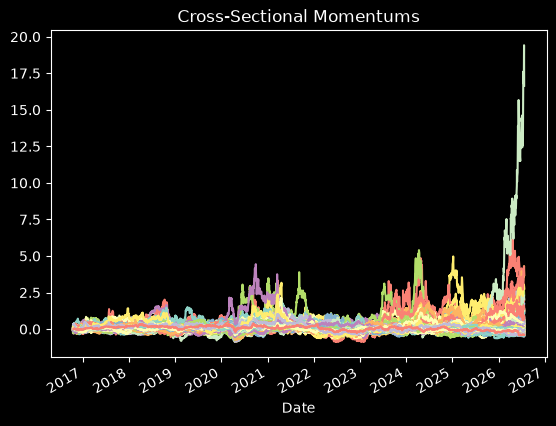

In [732]:
csm_data.plot(
    title='Cross-Sectional Momentums'
    , legend=False
)

### Part 4: Frog-in-the-Pan (FIP) Score: This factor measures the quality and consistency of a stock's trend.
- #### Mechanism: It calculates the ratio of positive daily returns over a 252-day period. A higher score indicates a smoother, more consistent uptrend, rather than one driven by a few large, volatile spikes.


In [733]:
LOOKBACK_FIP = 252

daily_ret = data.Close.pct_change()

up_days = (daily_ret > 0).rolling(LOOKBACK_FIP).sum()
down_days = (daily_ret < 0).rolling(LOOKBACK_FIP).sum()

cum_ret = data.Close.pct_change(LOOKBACK_FIP)
trend_sign = np.sign(cum_ret)

# Published FIP
fip = trend_sign * (down_days - up_days) / LOOKBACK_FIP

# Higher = better (invert for ranking)
fip_data = -fip

<Axes: title={'center': 'Frog in the Pan Scores'}, xlabel='Date'>

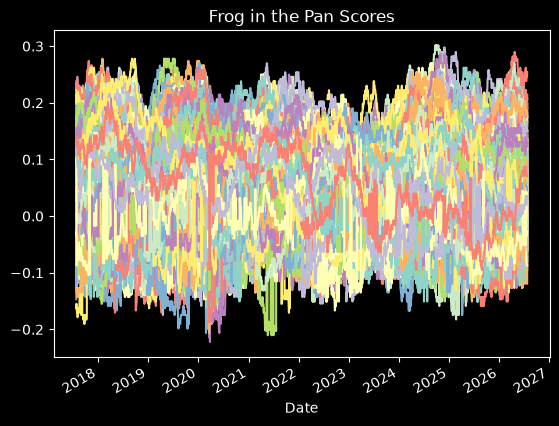

In [734]:
fip_data.plot(
    title='Frog in the Pan Scores'
    , legend=False
)

### Part 5: Skewness Factor: To mitigate the risk of holding stocks prone to sudden crashes, a skewness factor is included.
- #### Mechanism: It calculates the rolling skewness of stock returns over a 90-day window. A high negative skew suggests a stock has a "tail" of large negative returns and is thus penalized in its final score.

In [735]:
LOOKBACK_SKEW = 90
log_returns = np.log(data.Close).diff()
skew_data = log_returns.rolling(LOOKBACK_SKEW).skew()
skew_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-17,2.741793,-0.415795,0.448584,-0.129453,1.334523,-0.455219,-1.901694,-0.160743,-0.419906,0.090841,...,-0.040779,0.394723,0.229421,-0.452072,-0.222167,-0.093338,-0.284216,-1.493941,0.440930,-4.516099
2026-07-20,2.742576,-0.385128,0.452359,-0.135863,1.307308,-0.453048,-1.963719,-0.174328,-0.413619,0.124899,...,-0.025101,0.430083,0.226163,-0.489706,-0.209283,-0.082247,-0.285043,-1.497719,0.444339,-4.538044
2026-07-21,2.694555,-0.392459,0.437409,-0.114398,1.307854,-0.454909,-1.925882,-0.152668,-0.430800,0.142474,...,0.065625,0.439855,0.205434,-0.491008,-0.213787,-0.115003,-0.311755,-1.484085,0.460388,-4.529685
2026-07-22,2.771124,-0.405733,0.437801,-0.050346,1.283347,-0.440805,-1.959497,-0.143307,-0.469799,0.147997,...,0.033656,0.427789,0.175906,-0.490470,-0.225941,0.100196,-0.301137,-1.503947,0.494492,-4.608244
2026-07-23,2.627143,-0.404802,0.419279,-0.045590,1.278357,-0.476691,-1.947108,0.005457,-0.454053,0.151711,...,0.071624,0.424934,0.179572,-0.490749,-0.240195,0.111449,-0.281517,-1.505348,0.499277,-4.607473


<Axes: title={'center': 'Skew'}, xlabel='Date'>

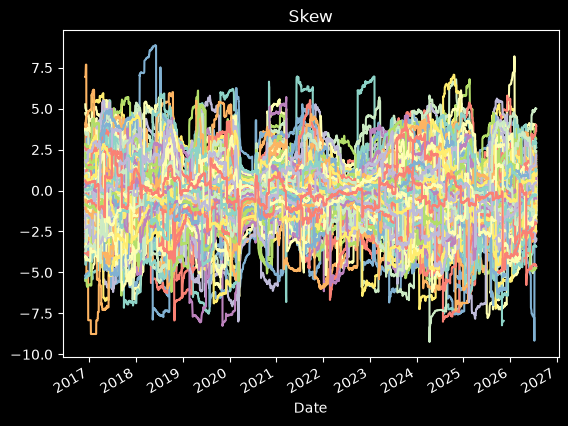

In [736]:
skew_data.plot(
    title='Skew'
    , legend=False
)

### Part 6: Inverse Volatility Weighting: This is a risk parity approach to portfolio construction.
- #### Mechanism: Once the top N stocks are selected, portfolio capital is allocated inversely proportional to each stock's historical volatility (standard deviation over 126 days). Less volatile stocks receive a larger capital allocation, and more volatile stocks receive a smaller one with the goal of equalizing the risk contribution of each position.

In [737]:
LOOKBACK_VOLATILITY = 126
vol_data = (
    np.log(data.Close)
    .diff()
    .rolling(LOOKBACK_VOLATILITY)
    .std()
)
vol_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-17,0.022863,0.017121,0.017251,0.020876,0.020726,0.013975,0.033519,0.027153,0.025739,0.016876,...,0.015659,0.021527,0.013279,0.018303,0.018059,0.032463,0.014493,0.020239,0.029044,0.028597
2026-07-20,0.022867,0.017234,0.017115,0.020887,0.020745,0.013973,0.033539,0.027164,0.025731,0.016698,...,0.015760,0.021535,0.013240,0.018290,0.017858,0.032457,0.014321,0.020282,0.029031,0.028602
2026-07-21,0.022714,0.017199,0.017130,0.020849,0.020777,0.014020,0.033596,0.027214,0.025823,0.016570,...,0.015781,0.021438,0.013238,0.018383,0.018019,0.032450,0.014315,0.020244,0.028916,0.028609
2026-07-22,0.022585,0.016887,0.017164,0.021012,0.020796,0.014093,0.033375,0.027374,0.025786,0.016581,...,0.015803,0.021315,0.013319,0.018440,0.017468,0.032283,0.013750,0.020238,0.028545,0.028626
2026-07-23,0.022814,0.016941,0.017186,0.020989,0.020797,0.014144,0.033236,0.027440,0.025712,0.016472,...,0.015808,0.021313,0.013329,0.018375,0.017366,0.032258,0.013731,0.020259,0.028578,0.028589


<Axes: title={'center': 'Volatility'}, xlabel='Date'>

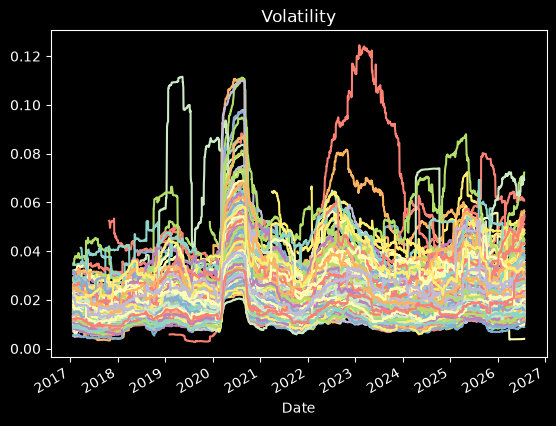

In [738]:
vol_data.plot(
    title='Volatility'
    , legend=False
)

# Signal Creation and Tuning

In [739]:
TRADE_FREQ : str = 'W-MON'

rebalances = (
    data.Close.index.to_series()
                    .resample(TRADE_FREQ)
                    .first()
                    .dropna()
)

In [740]:
signal_df = pd.DataFrame(
    0.0
    , columns=data.Close.columns
    , index = rebalances
)

# cash_signal = pd.Series(0.0, name='CASH', index=rebalances)

In [741]:
TOP_PCT     : float = 0.10
TOP_N       : int   = int(len(signal_df.columns) * TOP_PCT)
CSM_FACTOR  : int   = 3
FIP_FACTOR  : int   = 1 # 12
SKEW_FACTOR : int   = 1 # 10

In [742]:
latest_date = signal_df.index[-1]

def normalize(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

def build_signal(d: pd.Timestamp):
    ### Part 1: Market Regime Filter
    if mrf_signal.loc[d]:
        signal_df.loc[d] = 0.0
        # cash_signal.loc[d] = 1.0
        return

    ### Part 2: Time-Series Momentum (TSMOM)
    basket = signal_df.columns[tsmom_filter.loc[d]]
    # drop CASH from basket if tsmom_filter/columns alignment includes it
    # basket = basket.difference(cash_signal)

    csm = (
        normalize(csm_data.loc[d][basket][lambda x: x > 0])
        if not basket.empty else pd.Series(dtype=float)
    )

    if basket.empty or csm.empty:
        signal_df.loc[d] = signal_df.shift(1).loc[d]  # carry forward, already sums to 1
        return

    winners = csm.index

    ### Part 4: Frog-in-the-Pan (FIP) Score
    fip = normalize(fip_data.loc[d, winners])

    ### Part 5: Skewness Factor
    skew = normalize(skew_data.loc[d, winners])

    score = (
          (CSM_FACTOR  * csm)
        + (FIP_FACTOR  * fip)
        + (SKEW_FACTOR * skew)
    )
    top_picks = score.sort_values(ascending=False).head(TOP_N)

    ### Part 6: Inverse Volatility Weighting (risk parity within the stock sleeve)
    vol = vol_data.loc[d, top_picks.index]
    inv_vol = 1 / vol
    stock_weights = inv_vol / inv_vol.sum()  # sums to 1 within the sleeve

    ### Part 7: Portfolio-level vol targeting -> splits sleeve vs CASH
    signal_df.loc[d] = 0.0
    signal_df.loc[d, stock_weights.index] = stock_weights
    # cash_signal.loc[d] = 0.0

build_signal(latest_date)

signal_df.loc[latest_date].sort_values().tail(TOP_N + 1)  # +1 to also show CASH if it's near the top

Ticker
VRT     0.000000
SNDK    0.008085
LITE    0.009278
MU      0.010008
MRVL    0.010112
INTC    0.010231
TER     0.010333
COHR    0.010461
GLW     0.010496
WDC     0.010595
DELL    0.011084
FLEX    0.011576
STX     0.011627
CIEN    0.011702
AMD     0.011851
DDOG    0.012581
KLAC    0.012708
AKAM    0.012773
LRCX    0.013031
AMAT    0.013738
HPE     0.014650
FIX     0.015891
NXPI    0.016324
HUM     0.016449
CNC     0.017125
NTAP    0.017382
KEYS    0.017973
URI     0.018277
DVA     0.018545
FTNT    0.019404
CAT     0.020718
PWR     0.020800
CSCO    0.021892
CASY    0.023166
CVS     0.024527
A       0.025002
GS      0.025195
EXPD    0.025697
WST     0.026148
VTRS    0.026427
DOC     0.026910
MS      0.028571
MNST    0.031150
ROST    0.031151
NTRS    0.032899
STT     0.035023
UNP     0.035476
BNY     0.037243
AIZ     0.037426
D       0.040035
TRV     0.040254
Name: 2026-07-21 00:00:00, dtype: float64

In [743]:
for d in signal_df.index: build_signal(d)

# Evaluating Portfolio

### Calculatinga portfolio and benchmark returns 

In [744]:
df_returns = data.Close.apply(
    lambda x: np.log(x).diff().shift(-1)
    , axis=0
)

In [745]:
df_weights = signal_df.reindex(df_returns.index).ffill().fillna(0)

In [746]:
portfolio_returns = (df_returns * df_weights).ffill().sum(axis=1)

In [747]:
benchmark_returns = np.log(close_spy).diff().shift(-1)

In [748]:
SAMPLE_END_YEAR   = dt.date.today().year
SAMPLE_START_YEAR = SAMPLE_END_YEAR - 8

LOOKBACK_BENCHMARK : int = 63
TRADING_DAYS: int = 252

In [749]:
portfolio_returns = portfolio_returns[
      (portfolio_returns.index.year >= SAMPLE_START_YEAR)
    & (portfolio_returns.index.year <= SAMPLE_END_YEAR)
]

In [750]:
benchmark_returns = benchmark_returns[
      (benchmark_returns.index.year >= SAMPLE_START_YEAR)
    & (benchmark_returns.index.year <= SAMPLE_END_YEAR)
]

In [751]:
bearish_dates = mrf_signal[
      (mrf_signal.index.year >= SAMPLE_START_YEAR)
    & (mrf_signal.index.year <= SAMPLE_END_YEAR)
    & mrf_signal.eq(1)
].index

In [752]:
basket_count_indicator = tsmom_filter.sum(axis=1)
basket_count_indicator = basket_count_indicator[
      (basket_count_indicator.index.year >= SAMPLE_START_YEAR)
    & (basket_count_indicator.index.year <= SAMPLE_END_YEAR)
]

In [753]:
rolling_covariance = portfolio_returns.rolling(LOOKBACK_BENCHMARK).cov(
    benchmark_returns
)
rolling_variance = benchmark_returns.rolling(LOOKBACK_BENCHMARK).var()
rolling_beta = rolling_covariance / rolling_variance.replace(0, np.nan)

In [754]:
# alpha = mean(portfolio) - beta * mean(benchmark)
rolling_alpha = (
    portfolio_returns.rolling(LOOKBACK_BENCHMARK).mean()
    - rolling_beta
    * benchmark_returns.rolling(LOOKBACK_BENCHMARK).mean()
)

In [755]:
portfolio_equity = np.exp(portfolio_returns.cumsum())
benchmark_equity = np.exp(benchmark_returns.cumsum())

In [756]:
portfolio_running_max = portfolio_equity.cummax()
portfolio_drawdown    = (portfolio_equity - portfolio_running_max) / portfolio_running_max * 100

benchmark_running_max = benchmark_equity.cummax()
benchmark_drawdown    = (benchmark_equity - benchmark_running_max) / benchmark_running_max * 100

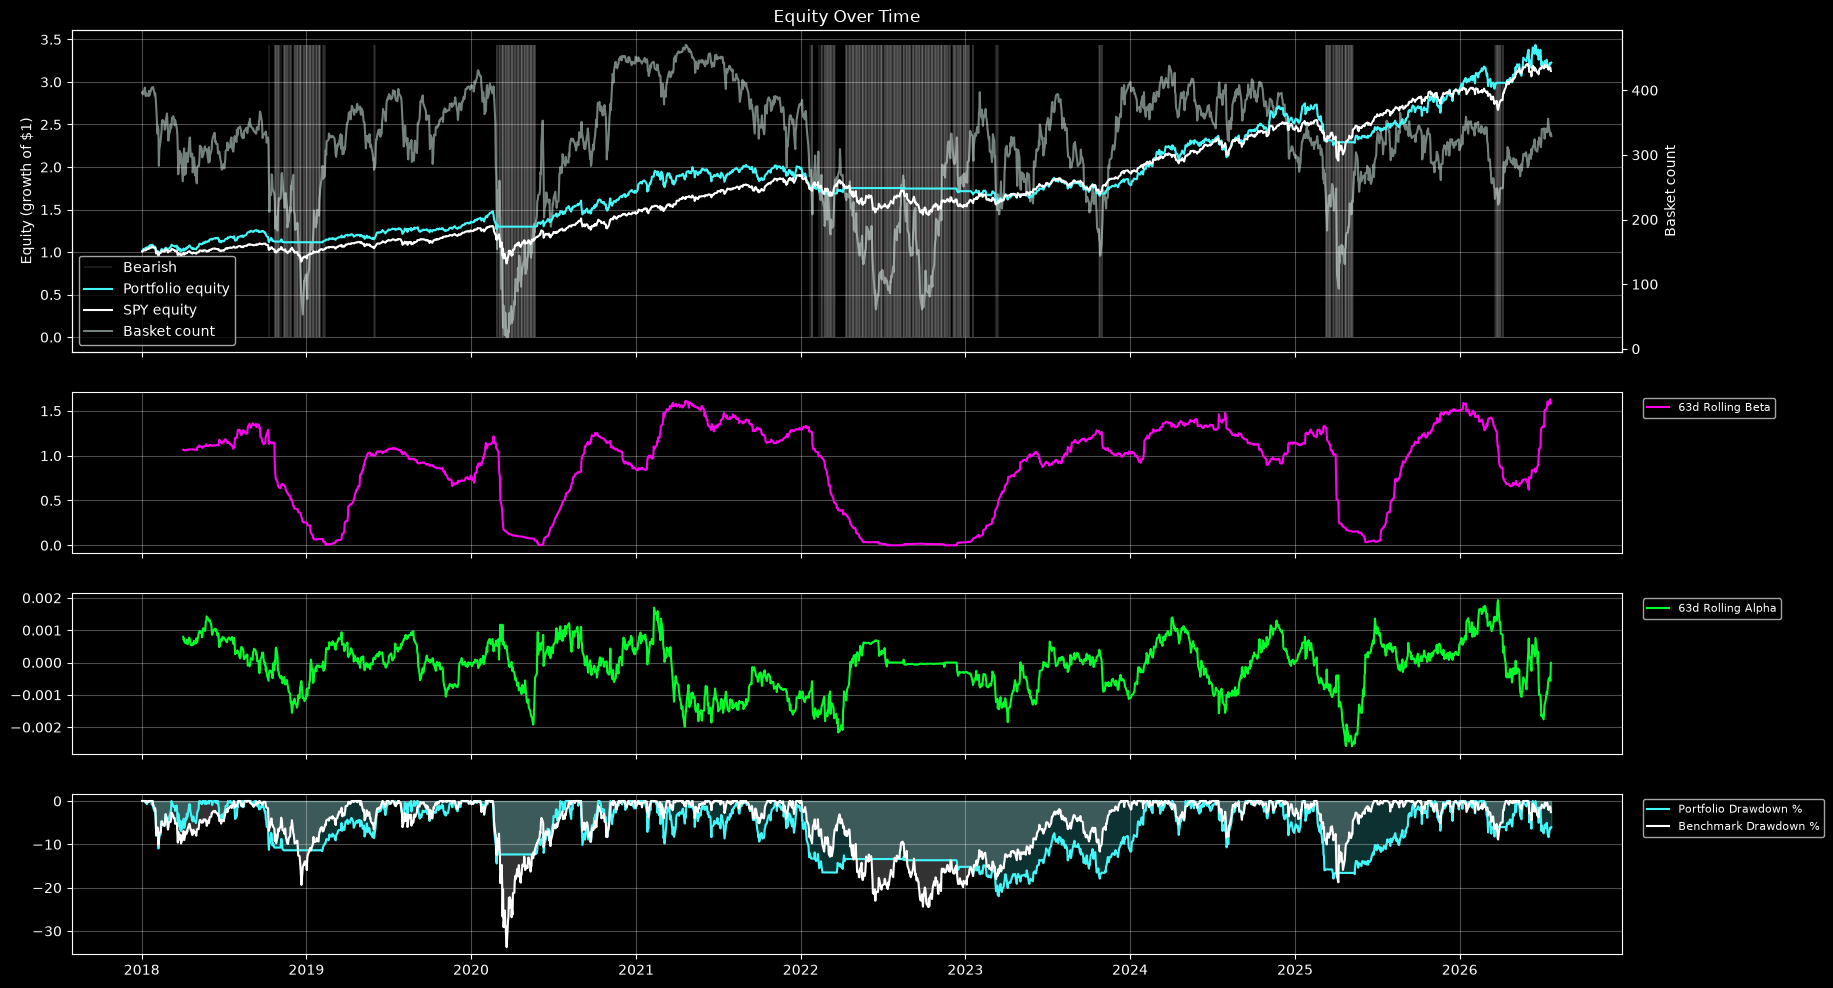

In [757]:
fig, axes = plt.subplots(
    4, 1
    , figsize=(20, 12)
    , gridspec_kw={'height_ratios': [2, 1, 1, 1]}
    , sharex=True
)

ymax = max(portfolio_equity.max(), benchmark_equity.max())

ax = axes[0]

ax.vlines(
    bearish_dates
    , ymin  = 0
    , ymax  = ymax
    , alpha = 0.1
    , color = 'white'
    , label = 'Bearish'
)


ax.plot(portfolio_equity, color="#42f7fa", label='Portfolio equity')
ax.plot(benchmark_equity, color='white', label='SPY equity')
ax.set_title('Equity Over Time')
ax.set_ylabel('Equity (growth of $1)')

ax_twin = ax.twinx()
ax_twin.plot(basket_count_indicator, color="#91A39C", alpha=0.8, label='Basket count')
ax_twin.set_ylabel('Basket count')

ax.set_zorder(ax_twin.get_zorder() + 1)
ax.patch.set_visible(False)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
ax.grid(True, alpha=0.3, color="#FFFFFF")

ax = axes[1]
ax.plot(rolling_beta, color="#FF00EE", label=f'{LOOKBACK_BENCHMARK}d Rolling Beta')

ax = axes[2]
ax.plot(rolling_alpha, color="#00FF2A", label=f'{LOOKBACK_BENCHMARK}d Rolling Alpha')

ax = axes[3]
ax.plot(portfolio_drawdown, color='#42f7fa', label='Portfolio Drawdown %')
ax.fill_between(portfolio_drawdown.index, portfolio_drawdown, 0, color='#42f7fa', alpha=0.2)

ax.plot(benchmark_drawdown, color='white', label='Benchmark Drawdown %')
ax.fill_between(benchmark_drawdown.index, benchmark_drawdown, 0, color='white', alpha=0.2)

for ax in axes[1:]:
    ax.grid(True, alpha=0.3, color="#FFFFFF")
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.show()

In [ ]:
### === Notes ===
# Depending on the number stocks you trade on `TOP_N` will increase risk for drawdown but I've seen lead to higher equity growth...